<a href="https://colab.research.google.com/github/rlaffonr/sprint4-final-project/blob/main/sprint4_final_project_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sprint 4 Project: E-Commerce Customer Behavior EDA

Welcome to your Sprint 4 final project. In this project, you will apply everything you've learned across Sprints 1–4 to perform a complete Exploratory Data Analysis on the **Olist Brazilian E-Commerce dataset** — real data from a real e-commerce platform.


## Dataset

You'll work with 7 CSV files from the Olist e-commerce dataset:

| File | Rows | Description |
|---|---|---|
| `olist_orders_dataset.csv` | 99,441 | Orders with timestamps and status |
| `olist_order_items_dataset.csv` | 112,650 | Items per order with price and freight |
| `olist_customers_dataset.csv` | 99,441 | Customer ID, city, state |
| `olist_products_dataset.csv` | 32,951 | Products with category and dimensions |
| `olist_order_reviews_dataset.csv` | 99,224 | Review scores (1–5 stars) |
| `olist_order_payments_dataset.csv` | 103,886 | Payment type and value |
| `product_category_name_translation.csv` | 71 | Portuguese → English category names |

Let's get started!

---

## Setup

Run the cells below to import the libraries you'll need and load the datasets. The data is hosted on GitHub, so you can load it with one line of code per file — no uploads required.

In [ ]:
# Import libraries
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# Confirm versions
print(f"pandas version: {pd.__version__}")
print("Setup complete!")

pandas version: 2.2.2
Setup complete!


In [ ]:
# Load the 7 datasets from the curriculum GitHub repo
BASE_URL = 'https://practicum-content.s3.us-west-1.amazonaws.com/data-analytics/eda-project/'

orders = pd.read_csv(BASE_URL + 'olist_orders_dataset.csv')
items = pd.read_csv(BASE_URL + 'olist_order_items_dataset.csv')
customers = pd.read_csv(BASE_URL + 'olist_customers_dataset.csv')
products = pd.read_csv(BASE_URL + 'olist_products_dataset.csv')
reviews = pd.read_csv(BASE_URL + 'olist_order_reviews_dataset.csv')
payments = pd.read_csv(BASE_URL + 'olist_order_payments_dataset.csv')
translation = pd.read_csv(BASE_URL + 'product_category_name_translation.csv')

print(f"orders:      {orders.shape}")
print(f"items:       {items.shape}")
print(f"customers:   {customers.shape}")
print(f"products:    {products.shape}")
print(f"reviews:     {reviews.shape}")
print(f"payments:    {payments.shape}")
print(f"translation: {translation.shape}")

orders:      (99441, 8)
items:       (112650, 7)
customers:   (99441, 5)
products:    (32951, 9)
reviews:     (99224, 7)
payments:    (103886, 5)
translation: (71, 2)


In [ ]:
# Set up an in-memory SQLite database with all 7 tables
# This lets you run SQL queries directly against the DataFrames
conn = sqlite3.connect(':memory:')

orders.to_sql('orders', conn, index=False, if_exists='replace')
items.to_sql('items', conn, index=False, if_exists='replace')
customers.to_sql('customers', conn, index=False, if_exists='replace')
products.to_sql('products', conn, index=False, if_exists='replace')
reviews.to_sql('reviews', conn, index=False, if_exists='replace')
payments.to_sql('payments', conn, index=False, if_exists='replace')
translation.to_sql('translation', conn, index=False, if_exists='replace')

print("SQLite database ready. You can now run SQL queries with pd.read_sql().")

SQLite database ready. You can now run SQL queries with pd.read_sql().


---

## Question 1: Inspect the orders DataFrame

**Your task:** For the `orders` DataFrame:
1. Print its shape
2. Print the first 5 rows with `.head()`
3. Print column info with `.info()`

This is the very first thing every analyst does with a new dataset.

*Skills: Sprint 4 Ch 01 (Pandas inspection)*

In [ ]:
# 1. Print the shape of the orders DataFrame
print(orders.shape)

# 2. Print the first 5 rows
print(orders.head())

# 3. Print column info
print(orders.info())


(99441, 8)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00       

---

## Question 2: Clean the orders data

The `orders` DataFrame has timestamp columns stored as strings, and a few have missing values.

**Your task:**
1. Use `.isnull().sum()` to count missing values in each column of `orders`
2. Convert `order_purchase_timestamp` and `order_delivered_customer_date` to datetime using `pd.to_datetime()`
3. Print the dtypes after conversion to verify

*Skills: Sprint 4 Ch 02 (Cleaning, dtype conversion)*

In [ ]:
# 1. Count missing values in each column of orders
print(orders.isnull().sum())

# 2. Convert timestamp columns to datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

# 3. Print dtypes to verify
print(orders.dtypes)


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                        object
order_delivered_carrier_date             object
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date            object
dtype: object


---

## Question 3: Order status breakdown (SQL)

**Your task:** Write a SQL query against the `orders` table that returns:
- `order_status`
- `num_orders` — count of orders with that status
- `pct` — percentage of total orders, rounded to 2 decimals

Sort by `num_orders` descending. Save the result to a DataFrame called `status_summary` and print it.

**Hint:** Use `pd.read_sql("...", conn)`. The percentage trick is `COUNT(*) * 100.0 / (SELECT COUNT(*) FROM orders)`.

*Skills: Sprint 2 (SQL aggregation), Sprint 4 Ch 03 (Descriptive stats)*

In [ ]:
# SQL query to count orders by status and calculate their percentage of the total
status_summary = pd.read_sql("""
    SELECT order_status,
           COUNT(*) AS num_orders,
           ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM orders), 2) AS pct
    FROM orders
    GROUP BY order_status
    ORDER BY num_orders DESC
""", conn)

# Print the final result
print(status_summary)


  order_status  num_orders    pct
0    delivered       96478  97.02
1      shipped        1107   1.11
2     canceled         625   0.63
3  unavailable         609   0.61
4     invoiced         314   0.32
5   processing         301   0.30
6      created           5   0.01
7     approved           2   0.00


---

## Question 4: Top 10 highest-revenue orders (SQL JOIN)

Each order can have multiple items. Total order revenue = sum of `price + freight_value` across all its items.

**Your task:** Write a SQL query that JOINs `orders` and `items` to find the **10 highest-revenue orders**. Return:
- `order_id`
- `order_status`
- `total_revenue` — rounded to 2 decimals

Save the result to `top_orders` and print it.

*Skills: Sprint 2 (SQL JOIN, GROUP BY), Sprint 4 Ch 06 (combining tables)*

In [ ]:
# Join orders and items to calculate total revenue per order, then get the top 10
top_orders = pd.read_sql("""
    SELECT o.order_id,
           o.order_status,
           ROUND(SUM(i.price + i.freight_value), 2) AS total_revenue
    FROM orders o
    JOIN items i ON o.order_id = i.order_id
    GROUP BY o.order_id, o.order_status
    ORDER BY total_revenue DESC
    LIMIT 10
""", conn)

# Print the result
print(top_orders)


                           order_id order_status  total_revenue
0  03caa2c082116e1d31e67e9ae3700499    delivered       13664.08
1  736e1922ae60d0d6a89247b851902527    delivered        7274.88
2  0812eb902a67711a1cb742b3cdaa65ae    delivered        6929.31
3  fefacc66af859508bf1a7934eab1e97f    delivered        6922.21
4  f5136e38d1a14a4dbd87dff67da82701    delivered        6726.66
5  2cc9089445046817a7539d90805e6e5a    delivered        6081.54
6  a96610ab360d42a2e5335a3998b4718a    delivered        4950.34
7  b4c4b76c642808cbe472a32b86cddc95     canceled        4809.44
8  199af31afc78c699f0dbf71fb178d4d4    delivered        4764.34
9  8dbc85d1447242f3b127dda390d56e19    delivered        4681.78


---

## Question 5: English product categories (pandas merge)

The `products` table has a Portuguese category column called `product_category_name`. The `translation` table maps each Portuguese name to its English equivalent.

**Your task:**
1. Use `products.merge(translation, on='product_category_name', how='left')` to add the English column. Save it to `products_eng`.
2. Find the **top 10 categories by number of products** using `value_counts()` on the `product_category_name_english` column. Save to `top_categories` and print it.

*Skills: Sprint 4 Ch 06 (pandas merge), Ch 03 (value_counts)*

In [ ]:
# Merge products with translation table to add English category names
products_eng = products.merge(translation, on='product_category_name', how='left')

# Count products per English category and get the top 10
top_categories = products_eng['product_category_name_english'].value_counts().head(10)

print(top_categories)


product_category_name_english
bed_bath_table           3029
sports_leisure           2867
furniture_decor          2657
health_beauty            2444
housewares               2335
auto                     1900
computers_accessories    1639
toys                     1411
watches_gifts            1329
telephony                1134
Name: count, dtype: int64


---

## Question 6: Revenue and average review score by category

Now you'll combine three tables and compute multiple metrics per category.

**Your task:**
1. Build a DataFrame that merges `items` with `products_eng` (to get categories), then merges with `reviews` (to get scores). The shared key chain is: `items.product_id → products_eng.product_id` and `items.order_id → reviews.order_id`.
2. Add a `revenue` column = `price + freight_value`
3. Group by `product_category_name_english` and aggregate:
   - `total_revenue` = sum of `revenue`
   - `avg_review` = mean of `review_score`
   - `n_items` = count of `order_id`
4. Sort by `total_revenue` descending and show the **top 10 categories**. Save to `category_summary`.

*Skills: Sprint 4 Ch 06 (multi-table merge, groupby with multiple aggregations)*

In [ ]:
# Merge items with products_eng to bring in category names
merged = items.merge(products_eng, on='product_id', how='inner')

# Merge the result with reviews to bring in review scores
merged = merged.merge(reviews, on='order_id', how='inner')

# Add a revenue column
merged['revenue'] = merged['price'] + merged['freight_value']

# Group by category and compute the metrics
category_summary = merged.groupby('product_category_name_english').agg(
    total_revenue=('revenue', 'sum'),
    avg_review=('review_score', 'mean'),
    n_items=('order_id', 'count')
).reset_index()

# Sort by total_revenue and take the top 10
category_summary = category_summary.sort_values('total_revenue', ascending=False).head(10)

print(category_summary)


   product_category_name_english  total_revenue  avg_review  n_items
43                 health_beauty     1434501.78    4.142768     9645
70                 watches_gifts     1297404.23    4.019160     5950
7                 bed_bath_table     1244950.00    3.895663    11137
65                sports_leisure     1155295.28    4.107986     8640
15         computers_accessories     1062184.42    3.930819     7849
39               furniture_decor      902472.18    3.903493     8331
49                    housewares      775827.36    4.055019     6943
20                    cool_stuff      712954.07    4.146341     3772
5                           auto      678859.45    4.065512     4213
42                  garden_tools      581483.25    4.042735     4329


---

## Question 7: Top 10 customer states (SQL + bar chart)

**Your task:**
1. Write a SQL query that returns the **top 10 customer states** by number of customers. Columns: `customer_state`, `num_customers`. Save to `state_top10`.
2. Create a **bar chart** of `num_customers` by `customer_state`. Add a title and rotate the x-tick labels if they overlap.

*Skills: Sprint 2 (SQL GROUP BY), Sprint 4 Ch 04 (bar chart)*

  customer_state  num_customers
0             SP          41746
1             RJ          12852
2             MG          11635
3             RS           5466
4             PR           5045
5             SC           3637
6             BA           3380
7             DF           2140
8             ES           2033
9             GO           2020


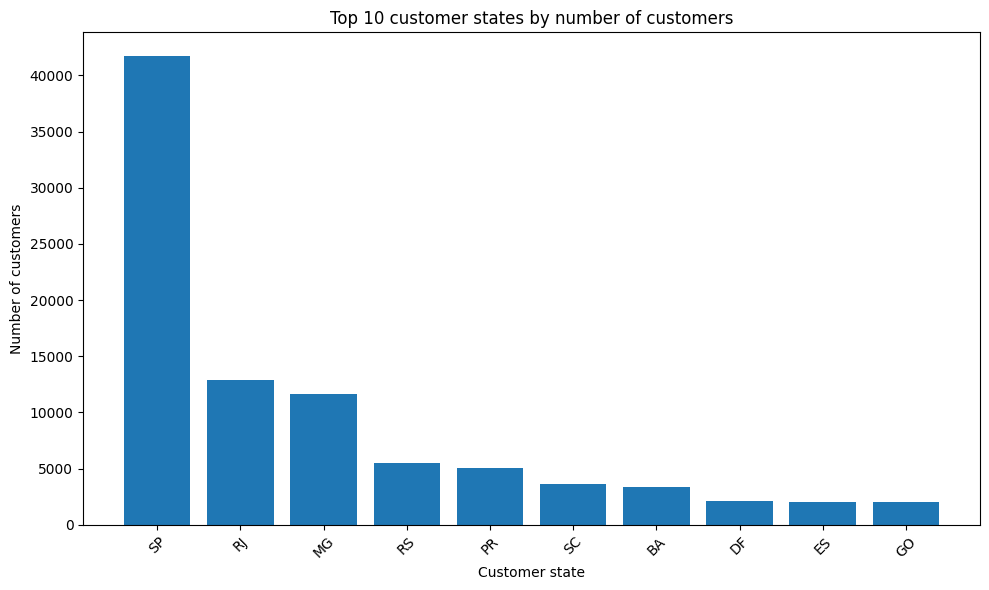

In [ ]:
# SQL query to get the top 10 customer states by number of customers
state_top10 = pd.read_sql("""
    SELECT customer_state,
           COUNT(*) AS num_customers
    FROM customers
    GROUP BY customer_state
    ORDER BY num_customers DESC
    LIMIT 10
""", conn)

# Print the result
print(state_top10)

# Bar chart of the top 10 customer states by number of customers
plt.figure(figsize=(10, 6))
plt.bar(state_top10['customer_state'], state_top10['num_customers'])
plt.title('Top 10 customer states by number of customers')
plt.xlabel('Customer state')
plt.ylabel('Number of customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

## Question 8: Monthly order trend (line chart)

**Your task:**
1. From the cleaned `orders` DataFrame (with datetime columns from Q2), extract a `year_month` period from `order_purchase_timestamp` using `.dt.to_period('M')`
2. Count orders per month — save to a DataFrame called `monthly_orders` with columns `year_month` and `num_orders`
3. Plot a **line chart** of `num_orders` over time. Add a title.

**Hint:** `orders['order_purchase_timestamp'].dt.to_period('M').value_counts().sort_index()` is a fast way to get monthly counts. Convert the period index back to string for plotting.

*Skills: Sprint 4 Ch 02 (datetime), Ch 03 (groupby), Ch 04 (line chart)*

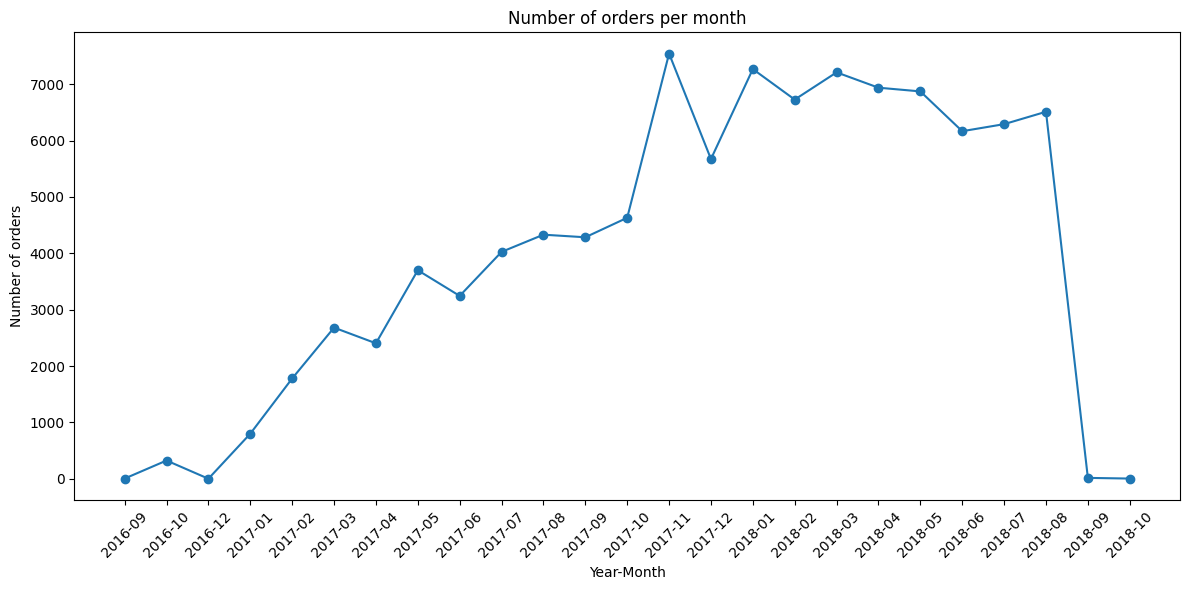

In [ ]:
# Extract year-month period, count orders per month, then plot as a line chart
orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = orders['year_month'].value_counts().sort_index().reset_index()
monthly_orders.columns = ['year_month', 'num_orders']

plt.figure(figsize=(12, 6))
plt.plot(monthly_orders['year_month'].astype(str), monthly_orders['num_orders'], marker='o')
plt.title('Number of orders per month')
plt.xlabel('Year-Month')
plt.ylabel('Number of orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

## Question 9: Does delivery speed affect review scores?

This is a real business question: do customers who get their orders faster leave better reviews?

**Your task:**
1. From `orders`, keep only rows where `order_delivered_customer_date` is not null
2. Add a `delivery_days` column = (delivery date − purchase date) in days. **Hint:** subtract the two datetime columns and use `.dt.days`
3. Merge with `reviews` on `order_id` to get the `review_score` for each order
4. Compute the **correlation** between `delivery_days` and `review_score` using `.corr()`
5. Group by `review_score` and show the **average delivery days** for each score (1 through 5)
6. Plot a bar chart of average delivery days by review score

What pattern do you see? Add a markdown cell with your interpretation.

*Skills: Sprint 4 Ch 03 (correlation), Ch 04 (visualization), Ch 06 (merge + groupby)*

Correlation between delivery_days and review_score: -0.3337
   review_score  delivery_days
0             1      20.849825
1             2      16.194832
2             3      13.795278
3             4      11.848054
4             5      10.224097


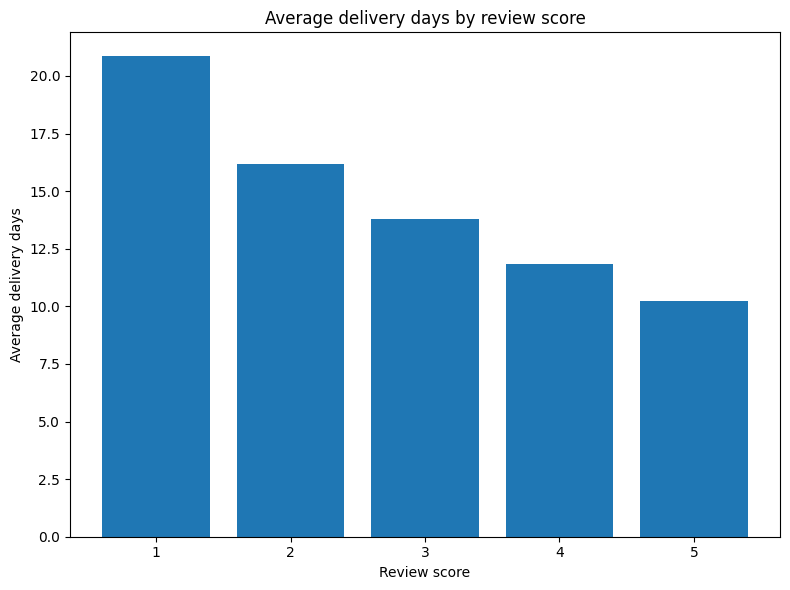

In [ ]:
# Filter delivered orders, compute delivery time, merge with reviews, and analyze delivery days vs review score
delivered = orders[orders['order_delivered_customer_date'].notnull()].copy()
delivered['delivery_days'] = (delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']).dt.days

merged_reviews = delivered.merge(reviews, on='order_id', how='inner')

correlation = merged_reviews['delivery_days'].corr(merged_reviews['review_score'])
print(f"Correlation between delivery_days and review_score: {correlation:.4f}")

avg_delivery_by_score = merged_reviews.groupby('review_score')['delivery_days'].mean().reset_index()
print(avg_delivery_by_score)

plt.figure(figsize=(8, 6))
plt.bar(avg_delivery_by_score['review_score'], avg_delivery_by_score['delivery_days'])
plt.title('Average delivery days by review score')
plt.xlabel('Review score')
plt.ylabel('Average delivery days')
plt.tight_layout()
plt.show()


## Interpretation

The correlation between delivery_days and review_score is negative, indicating that
longer delivery times are associated with lower review scores. The bar chart shows
average delivery days decreasing as review scores increase orders that received
a 5 star review took the least time to arrive on average, while orders with 1 star
reviews took considerably longer. This suggests that delivery speed is one of the
factors influencing customer satisfaction, though it's likely not the only one.

---

## Question 10: Final Report

Write a **2–3 paragraph executive summary** of your findings as a markdown cell below. A good report answers:

- **What is the overall health of the business?** (Use Q3, Q8 — order volumes and trends)
- **Which product categories should we double down on?** (Use Q6 — revenue + review scores together)
- **Where are our customers and how do we serve them?** (Use Q7, Q9 — geography and delivery speed)
- **What is one specific recommendation you would make to the leadership team?**

Write as if you're presenting to a non-technical executive. Use plain language. Reference specific numbers from your analysis.

*Skills: Sprint 4 Ch 06 (analytical reporting)*

## Executive Summary

### Business Health

Monthly orders climbed from essentially zero in September 2016 to a peak of roughly 7,500
in November 2017, and have generally held in the 6,000–7,000 range through most of 2018,
a strong, established run rate rather than a one-time spike. (The sharp drop to near-zero
in September/October 2018 reflects the dataset ending, not an actual business decline.)
Order fulfillment is also strong: 97.02% of all orders were successfully delivered, with
only 0.63% canceled and 0.61% marked unavailable, together, cancellations and
unavailability account for under 1.3% of orders, a small and manageable share.

### Top Categories

**health_beauty** is the category to double down on, it leads in revenue at 1,434,501.78
and also carries a strong average review score of 4.14 out of 5, showing customers are
buying it heavily and are satisfied with it. **watches_gifts** and **sports_leisure**
follow closely, also combining solid revenue (1,297,404 and 1,155,295 respectively) with
above average review scores (4.02 and 4.11). By contrast, **bed_bath_table** generates the
third highest revenue (1,244,950) but has the lowest average review score in the top 10
(3.90), and **computers_accessories** and **furniture_decor** show a similar pattern
(revenue in the top tier, reviews below 4.0), worth investigating for quality, shipping,
or product fit issues before investing further.

### Customer Geography & Delivery

Our customers are heavily concentrated in **São Paulo (SP)**, with 41,746 customers, more
than three times the next largest state, Rio de Janeiro (RJ, 12,852). Minas Gerais (MG,
11,635) rounds out the top three, and the remaining states in the top 10 each have under
5,500 customers, showing a long tail. Delivery speed clearly affects satisfaction: the
correlation between delivery_days and review_score is 0.33 (negative), and the pattern is
consistent and sizable, orders rated 1 star took an average of 20.8 days to arrive, while
orders rated 5 stars took only 10.2 days, roughly half as long.

### Recommendation

Leadership should prioritize cutting delivery times, especially outside the SP/RJ/MG core,
since delivery speed shows the clearest, most consistent link to customer satisfaction
across the entire dataset, a 1 star order takes on average twice as long to arrive as a
5 star order. Given SP alone represents the largest customer base, even modest delivery
improvements there could have an outsized impact on overall review scores and repeat
purchases. With order volume growing and 97% of orders already delivered successfully,
fulfillment speed, not order completion, is the clearest lever to protect and improve
customer satisfaction going forward.